In [1]:
import numpy as np
import pandas as pd
import cobra
from cobra.io import read_sbml_model
import matplotlib.pyplot as plt 

### 1. Import Human-GEM (https://pmc.ncbi.nlm.nih.gov/articles/PMC7331181/)
##### N.B. I like to use this model since it can be further interrogated outside of the Jupyter environment using their portal: https://metabolicatlas.org/

In [106]:
model = read_sbml_model('Human-GEM-annotated.xml') #this is the unconstrained model
original_model = model
model #print model just to look through it

Name,HumanGEM
Memory address,1cac9c3a990
Number of metabolites,8400
Number of reactions,13096
Number of genes,3628
Number of groups,143
Objective expression,1.0*biomass_human - 1.0*biomass_human_reverse_fb2f2
Compartments,"Cytosol, Extracellular, Lysosome, Endoplasmic reticulum, Mitochondria, Peroxisome, Golgi apparatus, Nucleus, Inner mitochondria"


#### We will constrain this generic Human GEM to represent the OV56 ovarian cancer cell line. Ovarian cancer can be divided into five subtypes, which could have distinct metabolic profiles. One way to investigate this is through constraint-based modelling, translating changes in the expression of enzyme-encoding genes to predicted changes in metabolic flux. 

#### For further reading on ovarian cancer subtypes, see PMID: 31118829 (Momenimovahed et al, 2019) (https://pmc.ncbi.nlm.nih.gov/articles/PMC6500433/)

#### We previously determined these reaction boundaries from transcriptomics using the algorithm from Meeson et al, 2024 (PMID: 39181893) (https://pubmed.ncbi.nlm.nih.gov/39181893/) (https://www.biorxiv.org/content/10.1101/2025.06.24.661329v1)
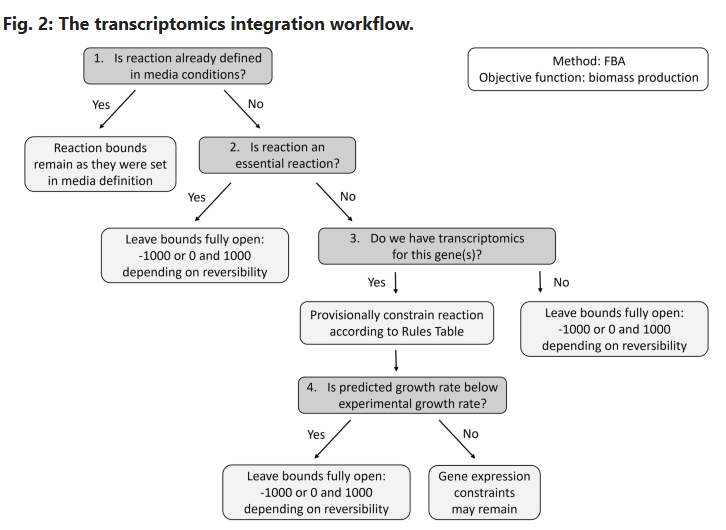
#### The metabolic fluxes and gene dependencies of this cell line have been recently validated in a subsequent pre-print (https://www.biorxiv.org/content/10.1101/2025.06.24.661329v1)

### 2. Constrain the model for media conditions (here, DMEM-F12)
##### N.B. there are notebookds for this algorithm on https://github.com/katemeeson/PhD_2024/tree/main/media_conditions 
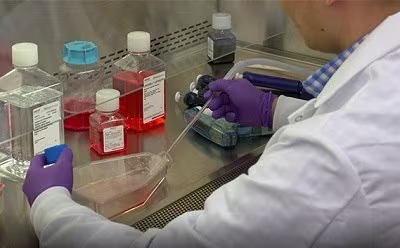

#### 2a. Import CSV file containing media conditions. 
#### - These are g/L concentrations translated to the lower bounds (import) of metabolites in the exchange reactions. Exchange reactions happen at the boundary of the cell and determine what is available intracellularly, so they can be used as a proxy for media conditions. I have used the code in this notebook to set these media conditions: Setting_media_constraints_function.ipynb
#### - DMEM:F12 formulation from https://www.thermofisher.com/uk/en/home/technical-resources/media-formulation.55.html


In [102]:
media_csv = pd.read_csv(r'DMEM_F12_all_bounds.csv')
print(media_csv.head())

                   Component  g/L  reaction   lb    ub
0   -1.0 benzo[a]pyrene <-->  0.0  HMR_7108  0.0  1000
1      -1.0 naphthalene <-->  0.0  HMR_7110  0.0  1000
2     -1.0 aflatoxin B1 <-->  0.0  HMR_7112  0.0  1000
3  -1.0 trichloroethene <-->  0.0  HMR_7114  0.0  1000
4     -1.0 bromobenzene <-->  0.0  HMR_7116  0.0  1000


In [111]:
with model: 
    for n in range(len(media_csv)):
        model.reactions.get_by_id(media_csv.iloc[n,2]).bounds = (media_csv.iloc[n,3],media_csv.iloc[n,4])
    media_model = model.copy() #save a version of the model with media conditions

#### 2b. Study the predicted growth before and after media constraints (Sanity check: it should be more realistic now!)

In [112]:
# Solve FBA optimising for biomass maximisation on original (no media) model
objective = {original_model.reactions.get_by_id('biomass_human'):1}
original_solution = original_model.optimize()
original_growth = original_solution.fluxes['biomass_human']
print('Original (no media) growth was:',original_growth,'g/gDW/hour','==',1/original_growth,'hours per cell division')

# Solve FBA optimising for biomass maximisation on media-constrained model
objective = {media_model.reactions.get_by_id('biomass_human'):1}
media_solution = media_model.optimize()
media_growth = media_solution.fluxes['biomass_human']
print('Growth on DMEM-F12 media was:',media_growth,'g/gDW/hour','==',1/media_growth,'hours per cell division')

Original (no media) growth was: 187.35362997658078 g/gDW/hour == 0.0053375 hours per cell division
Growth on DMEM-F12 media was: 0.08454106280193237 g/gDW/hour == 11.82857142857143 hours per cell division


#### We can see that with media conditions the cell is predicted to grow more slowly. This is because before we added the media conditions to our model, there was unlimited exchange of all metabolites into and out of the cell. Now, the exchange reactions have been limited to what we know is in the media. The predicted growth would be different if we specified a different media, this is why it's important to match the model's constraints to the sample we're trying to model

### 3. Constrain the model with gene expression measurements
##### N.B. RNA sequencing gene expression measurements are from the Cancer Cell Line Encyclopedia, and were taken from OV56 cells grown in DMEM:F12 media
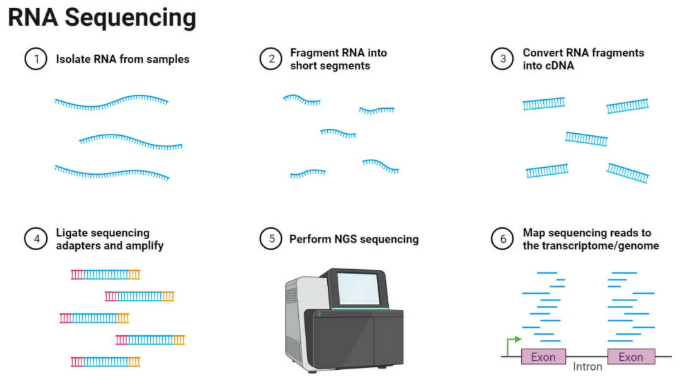

#### 3a. Import the CSV containing reactions and boundaries (defined previously according to algorithm in Meeson et al, 2024 (PMID: 39181893)

In [139]:
gene_expression_csv = pd.read_csv(r'Gene_expression_constraints_OV56.csv')
print(gene_expression_csv.head())

  Reaction_ID lb        ub
0    HMR_3907  0  7.614195
1    HMR_4097  0  5.669027
2    HMR_4108  0  5.669027
3    HMR_4133  0  5.669027
4    HMR_4360  0  2.361768


In [145]:
print('We are looking to constrain',len(gene_expression_csv),'reactions in the Human-GEM')
print('This represents',(len(gene_expression_csv)/(len(model.reactions)-len(model.exchanges)))*100,'% coverage of the total model reactions')

Could not identify an external compartment by name and choosing one with the most boundary reactions. That might be complete nonsense or change suddenly. Consider renaming your compartments using `Model.compartments` to fix this.


We are looking to constrain 7727 reactions in the Human-GEM
This represents 67.64422656044822 % coverage of the total model reactions


C:\Users\p04121km\AppData\Local\anaconda3\envs\prosperity_project\Lib\site-packages\cobra\medium\boundary_types.py:97: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return most[0]


#### 3b. Create dictionary from gene expression constraints, since this is a much larger dataframe than media conditions

In [140]:
gene_expression_csv['lb'] = pd.to_numeric(gene_expression_csv['lb'], errors='coerce') #make sure lower bound is a float64 instead of string object
gene_expression_csv['ub'] = pd.to_numeric(gene_expression_csv['ub'], errors='coerce') #make sure the upper bound is a float64 instead of a string object
gene_dict = dict(zip(gene_expression_csv['Reaction_ID'], zip(gene_expression_csv['lb'], gene_expression_csv['ub']))) #convert dataframe to dictionary
print(gene_dict)

{'HMR_3907': (0.0, 7.614194504), 'HMR_4097': (0.0, 5.669026766), 'HMR_4108': (0.0, 5.669026766), 'HMR_4133': (0.0, 5.669026766), 'HMR_4360': (0.0, 2.361768359), 'HMR_4372': (0.0, 4.409390936), 'HMR_7747': (0.0, 4.951867504), 'HMR_8360': (0.0, 4.274261661), 'HMR_8757': (0.0, 2.114367025), 'HMR_5397': (0.0, 5.437960088), 'HMR_5399': (0.0, 2.250961574), 'HMR_5400': (0.0, 2.250961574), 'HMR_8592': (0.0, 5.426264755), 'HMR_8589': (0.0, 5.426264755), 'HMR_8583': (0.0, 0.150559677), 'HMR_8584': (0.0, 0.0), 'HMR_8585': (0.0, 2.435628594), 'HMR_3944': (0.0, 5.705425039), 'HMR_4132': (0.0, 3.991861931), 'HMR_8761': (0.0, 1.042644337), 'HMR_8764': (0.0, 0.028569152), 'HMR_8767': (0.0, 3.991861931), 'HMR_4310': (0.0, 1.042644337), 'HMR_4399': (0.0, 3.349082146), 'HMR_4400': (0.0, 6.377644358), 'HMR_8768': (0.0, 6.377644358), 'HMR_4590': (0.0, 5.271276259), 'HMR_4593': (0.0, 4.263785614), 'HMR_4594': (0.0, 0.757023247), 'HMR_8726': (0.0, 3.129283017), 'HMR_8727': (0.0, 5.247168), 'HMR_8729': (0.0, 

#### 3c. Add gene expression constraints to reactions

In [141]:
with media_model: 
    for k,v in gene_dict.items():
        media_model.reactions.get_by_id(k).bounds = gene_dict[k]
        print(k,'bounds set to',gene_dict[k])
    gene_expression_model = media_model.copy() #save a version of the model with media conditions

HMR_3907 bounds set to (0.0, 7.614194504)
HMR_4097 bounds set to (0.0, 5.669026766)
HMR_4108 bounds set to (0.0, 5.669026766)
HMR_4133 bounds set to (0.0, 5.669026766)
HMR_4360 bounds set to (0.0, 2.361768359)
HMR_4372 bounds set to (0.0, 4.409390936)
HMR_7747 bounds set to (0.0, 4.951867504)
HMR_8360 bounds set to (0.0, 4.274261661)
HMR_8757 bounds set to (0.0, 2.114367025)
HMR_5397 bounds set to (0.0, 5.437960088)
HMR_5399 bounds set to (0.0, 2.250961574)
HMR_5400 bounds set to (0.0, 2.250961574)
HMR_8592 bounds set to (0.0, 5.426264755)
HMR_8589 bounds set to (0.0, 5.426264755)
HMR_8583 bounds set to (0.0, 0.150559677)
HMR_8584 bounds set to (0.0, 0.0)
HMR_8585 bounds set to (0.0, 2.435628594)
HMR_3944 bounds set to (0.0, 5.705425039)
HMR_4132 bounds set to (0.0, 3.991861931)
HMR_8761 bounds set to (0.0, 1.042644337)
HMR_8764 bounds set to (0.0, 0.028569152)
HMR_8767 bounds set to (0.0, 3.991861931)
HMR_4310 bounds set to (0.0, 1.042644337)
HMR_4399 bounds set to (0.0, 3.349082146)


#### 3d. Study how the gene expression constraints affect the growth rate predicted by the model 

In [146]:
# Solve FBA optimising for biomass maximisation on original (no media) model
objective = {original_model.reactions.get_by_id('biomass_human'):1}
original_solution = original_model.optimize()
original_growth = original_solution.fluxes['biomass_human']
print('Original (no media) growth was:',original_growth,'g/gDW/hour','==',1/original_growth,'hours per cell division')

# Solve FBA optimising for biomass maximisation on media only model
objective = {media_model.reactions.get_by_id('biomass_human'):1}
media_solution = media_model.optimize()
media_growth = media_solution.fluxes['biomass_human']
print('Growth on DMEM-F12 media was:',media_growth,'g/gDW/hour','==',1/media_growth,'hours per cell division')

# Solve FBA optimising for biomass maximisation on gene expression (and media) constrained model
objective = {gene_expression_model.reactions.get_by_id('biomass_human'):1}
gene_expression_solution = gene_expression_model.optimize()
gene_expression_growth = gene_expression_solution.fluxes['biomass_human']
print('Growth with both gene expression and media constraints was:',gene_expression_growth,'g/gDW/hour','==',1/gene_expression_growth,'hours per cell division')

Original (no media) growth was: 187.35362997658078 g/gDW/hour == 0.0053375 hours per cell division
Growth on DMEM-F12 media was: 0.08454106280193237 g/gDW/hour == 11.82857142857143 hours per cell division
Growth with both gene expression and media constraints was: 0.04394903268087986 g/gDW/hour == 22.75362935200739 hours per cell division


### 4. Compare model predictions to experimental (validation)
#### Now that we have built a model we hope reflects OV56 more than the generic Human-GEM, we should compare the predicted growth to the experimental growth and look how close we have gotten. For other organisms, e.g. E.coli, you may have access to the flux through other reactions such as glucose or glycerol consumption/production, but for human models, growth rate is a good experimental validation 
##### N.B. I use ChatGPT to help me make nice plots :)

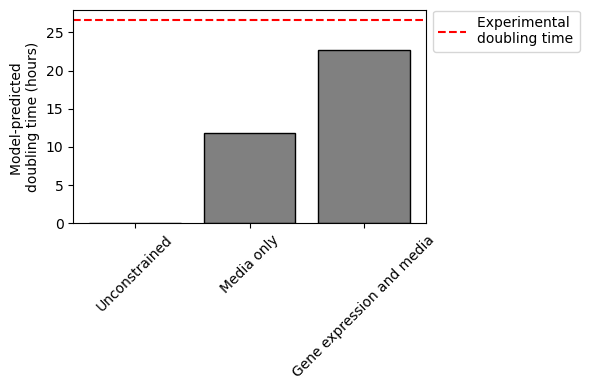

In [157]:
predictions = {'Unconstrained':1/original_growth,
               'Media only':1/media_growth,
              'Gene expression and media':1/gene_expression_growth} #create a dictionary with predictions to plot
experimental_doubling_time = 26.6 #this is from my own measurements, presented in pre-print: https://www.biorxiv.org/content/10.1101/2025.06.24.661329v1.full

# Extract keys and values
keys = list(predictions.keys())
values = list(predictions.values())

# Create the plot
plt.figure(figsize=(6, 4))
plt.bar(keys, values, color='grey', edgecolor='black')

# Add a horizontal line (y-intercept) at a specific value, e.g., 4.0
plt.axhline(y=experimental_doubling_time, color='red', linestyle='--', label='Experimental \ndoubling time')

# Labels and title
plt.ylabel("Model-predicted \ndoubling time (hours)")
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.9))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### We have learnt in this tutorial how we could go from a generic human genome-scale model to a model personalised to a particular cell line. Here, we have personalised the model using media conditions and gene expression data.

### Other ways you could personalise a GEM include (but are not limited to): proteomics, direct flux measurements, or kinetic information

### Now you have validated the functionality of the model using the experimental growth rate, it is ready for simulation. You could, for example: run gene engineering simulations, predict media optimisation strategies or compare a model built using 'healthy' control data to the ovarian cancer model to predict changes in metabolic profiles upon tumorigenesis. There are many great tutorials on the COBRA page: https://opencobra.github.io/cobratoolbox/stable/tutorials/